In [1]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.insert(0,homepath)

%load_ext autoreload 
%autoreload 2

import numpy as np
from explicit_solvent_sim import add_solvent
import gemmi

In [6]:
# configs, options = get_pipeline_configs(is_it_poisson)
# number_of_repeats = configs["number_of_repeats"]
# occupancy_levels = configs["occupancy_levels"]
# poisson_snr = configs["poisson_snr"]
# flat_snr = configs["flat_snr"]
from configuration import load_homepath

synthloc = load_homepath() + "synthetic_cistrans/"
pdbloc_dark = synthloc + "trans.pdb"
pdbloc_light = synthloc + "100ps.pdb"
struc = gemmi.read_structure(pdbloc_dark)
solvent, no_solvent = add_solvent(struc, dmin=2.0, solvent_level=0.3)


AtomicRadiiSet.Cctbx


H  K  L
0  0  0    0.074914
      1    0.695191
      2    0.154417
      3    0.783421
   1  0    0.716766
      1    0.382698
      2   -0.339795
      3    0.192961
   2  0   -0.034787
      1    0.151165
      2    0.037134
   3  0    0.433774
      1    0.214055
1  0  0    0.345698
      1    0.079014
      2    0.074591
      3    0.058205
   1  0    0.102318
      1    0.130737
      2    0.102125
      3    0.036424
   2  0     0.31617
      1    0.112272
      2    0.149476
2  0  0    0.312854
      1   -0.563238
      2    0.015852
   1  0   -0.002356
      1    0.072492
   2  0    0.031094
Name: F, dtype: SFAmplitude


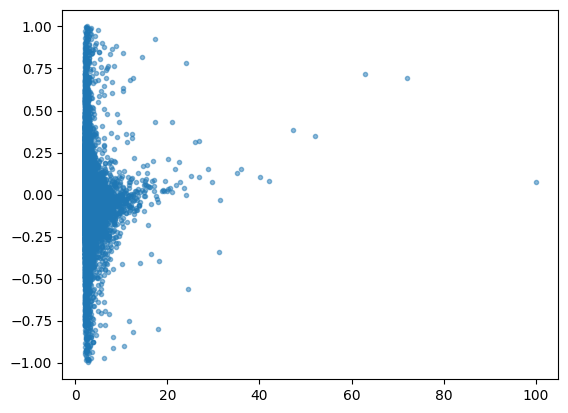

In [10]:
differences = (solvent.amplitudes-no_solvent.amplitudes)/(no_solvent.amplitudes+solvent.amplitudes)
import matplotlib.pyplot as plt
dhkl = solvent.compute_dHKL()
print(differences[dhkl>20])
dhkl[dhkl>100] = 100
plt.plot(dhkl, differences.values,'.', alpha=0.5)

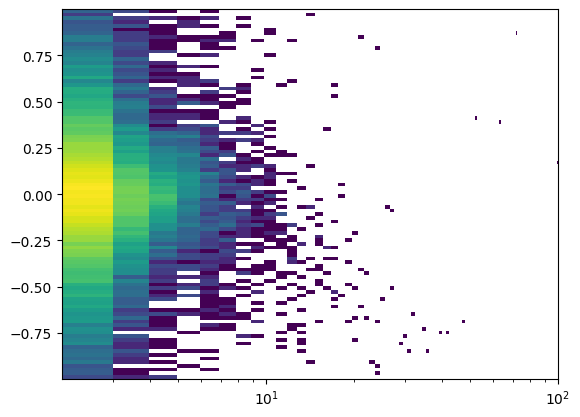

In [4]:
plt.hist2d(dhkl, differences.values, bins=100, norm="log")
plt.xscale('log')

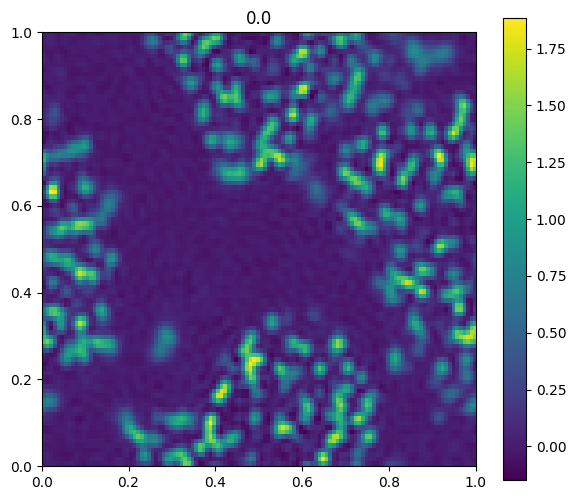

interactive(children=(IntSlider(value=0, description='f0', max=79), Output()), _dom_classes=('widget-interact'…

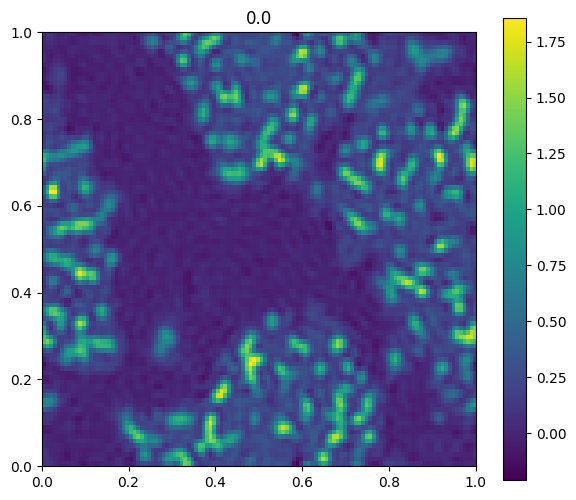

interactive(children=(IntSlider(value=0, description='f0', max=79), Output()), _dom_classes=('widget-interact'…

In [11]:
from plotting3d import slice_3d
map_nps=[mp.to_3d_numpy_map(map_sampling=3) for mp in [no_solvent, solvent]]
slice_3d(map_nps[0])
_ = slice_3d(map_nps[1])